In [215]:
from nrem_sc.constants import PROCESSED_DATA_PATH, INTERIM_DATA_PATH

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import pynapple as nap

from matplotlib import pyplot as plt
from cmap import Colormap

# ── Global style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       320,
    "font.family":       "arial",
    "font.size":         22,
    "axes.titlesize":    26,
    "axes.labelsize":    22,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         False,
    "legend.frameon":    False,
    "figure.constrained_layout.use": True,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
})

# ── Cyclic colormap ────────────────────────────────────────────────────────
cmap = Colormap("cmocean:phase")
if "cmocean:phase" not in mpl.colormaps:
    mpl.colormaps.register(cmap.to_mpl())


# ── Helpers ────────────────────────────────────────────────────────────────
set2 = Colormap('colorbrewer:Set2').color_stops
STATE_STYLES = {
    "stationary":  dict(color=set2[0].color.hex, label="Stationary"),
    "fragmented":  dict(color=set2[1].color.hex, label="Fragmented"),
    "continuous":  dict(color=set2[2].color.hex, label="Continuous"),
    }

def clean_axes(*axes, ylabel=None, xlabel=None):
    """Apply shared cosmetic cleanup to one or more axes."""
    for ax in axes:
        ax.tick_params(left=False, labelleft=False)
    if ylabel and axes:
        axes[0].set_ylabel(ylabel)
    if xlabel and axes:        axes[-1].set_xlabel(xlabel)

## Load data & compute tuning curves

In [2]:
unit_id = "116b"

# Data
sleep_states = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sleep.npz")
hd_spikes    = nap.load_file(PROCESSED_DATA_PATH / unit_id / "hd_spikes_filtered.npz")
hd_angle     = np.deg2rad(nap.load_file(PROCESSED_DATA_PATH / unit_id / "angle_openfield.npz"))
sessions     = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sessions_labeled.npz")
states       = nap.TsdFrame(pd.read_csv(PROCESSED_DATA_PATH / unit_id / "post_ttx_decoded_states.csv", index_col=0))

from scipy.ndimage import gaussian_filter1d
tcs = nap.compute_tuning_curves(
    data=hd_spikes.restrict(hd_angle.time_support), features=hd_angle, bins=60,
    epochs=hd_angle.time_support, range=(0.0, 2*np.pi), feature_names=['head_direction']
    )
tcs.values = gaussian_filter1d(tcs.values, sigma=3, axis=1, mode="wrap")
pref_ang = tcs.idxmax(dim="head_direction")
# tcs, pref_ang = hd_tuning(hd_spikes, hd_angle, n_bins=60)

In [13]:
# sweeps = [35052, 35108, 35196, 35226, 35291, 35475, 35633, 36032, 36284]
sweeps = {'start':[35107.7, 35290.0, 35632.],
          'end':[35109.7, 35292.0, 35634.]}
sweeps = nap.IntervalSet(start=sweeps['start'], end=sweeps['end'])

In [23]:
states = nap.load_file('tmp/116b_states.npz').restrict(sweeps.time_span())
position = nap.load_file('tmp/116b_position.npz').restrict(sweeps.time_span())

## Select sweep window

In [18]:
spikes = hd_spikes.restrict(sweeps)
active = spikes[spikes["rate"] > 0].index

# Sorted colours for cyclic ordering
sorted_pref  = pref_ang.sortby(pref_ang)
sorted_units = sorted_pref.coords[sorted_pref.dims[0]].values
sorted_colors = cmap(sorted_pref.values / (2 * np.pi))

# Normalized tuning curves sorted by preferred angle
norm_tcs = (tcs - tcs.min(dim="head_direction")) / (tcs.max(dim="head_direction") - tcs.min(dim="head_direction"))
norm_tcs = norm_tcs.sortby(pref_ang)

### Example sweep trajectories

In [ ]:
# ── Tuning curves (standalone) ──────────────────────────────────────────────
fig_tc, ax_tc = plt.subplots(figsize=(3, 8))

offset = 0.4
for i, uid in enumerate(sorted_units):
    if uid not in active:
        continue
    c = sorted_colors[i]
    ax_tc.plot(tcs["head_direction"], norm_tcs[i, :] + offset, color=c)
    offset += 1

ax_tc.set_ylim(0, 70)
ax_tc.set_xlim(0, 2 * np.pi)
ax_tc.set_xticks([0, 2 * np.pi], labels=["0", "360"])
ax_tc.set_xlabel("Head [deg]")
ax_tc.set_yticks([0, 70])
ax_tc.set_ylabel("HD cells")
plt.show()
fig_tc.savefig(INTERIM_DATA_PATH / unit_id / "sweep_tuning_curves.pdf", format="pdf", bbox_inches="tight", transparent=True)

Tuning curve polar plot (standalone)

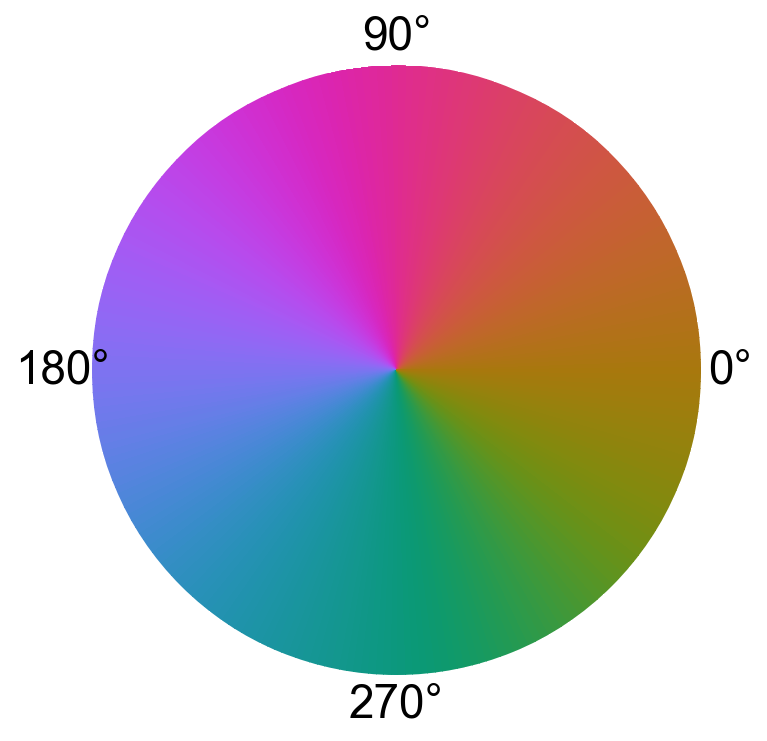

In [214]:
fig_disc, ax_disc = plt.subplots(figsize=(5, 5), subplot_kw={"projection": "polar"})

theta = np.linspace(0, 2 * np.pi, 256)
radii = np.linspace(0.5, 1, 2)
T, R = np.meshgrid(theta, radii)

ax_disc.pcolormesh(T, R, T, cmap="cmocean:phase", shading="auto")
ax_disc.set_yticks([])
ax_disc.set_xticks([])
ax_disc.set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2],
                   labels=["0°", "90°", "180°", "270°"])
ax_disc.spines["polar"].set_visible(False)
ax_disc.spines
ax_disc.grid(False)
plt.show()
# fig_disc.savefig(INTERIM_DATA_PATH / unit_id / "sweep_disc_colormap.pdf", format="pdf", transparent=True)

Raster, State Probabilities and Decoding 

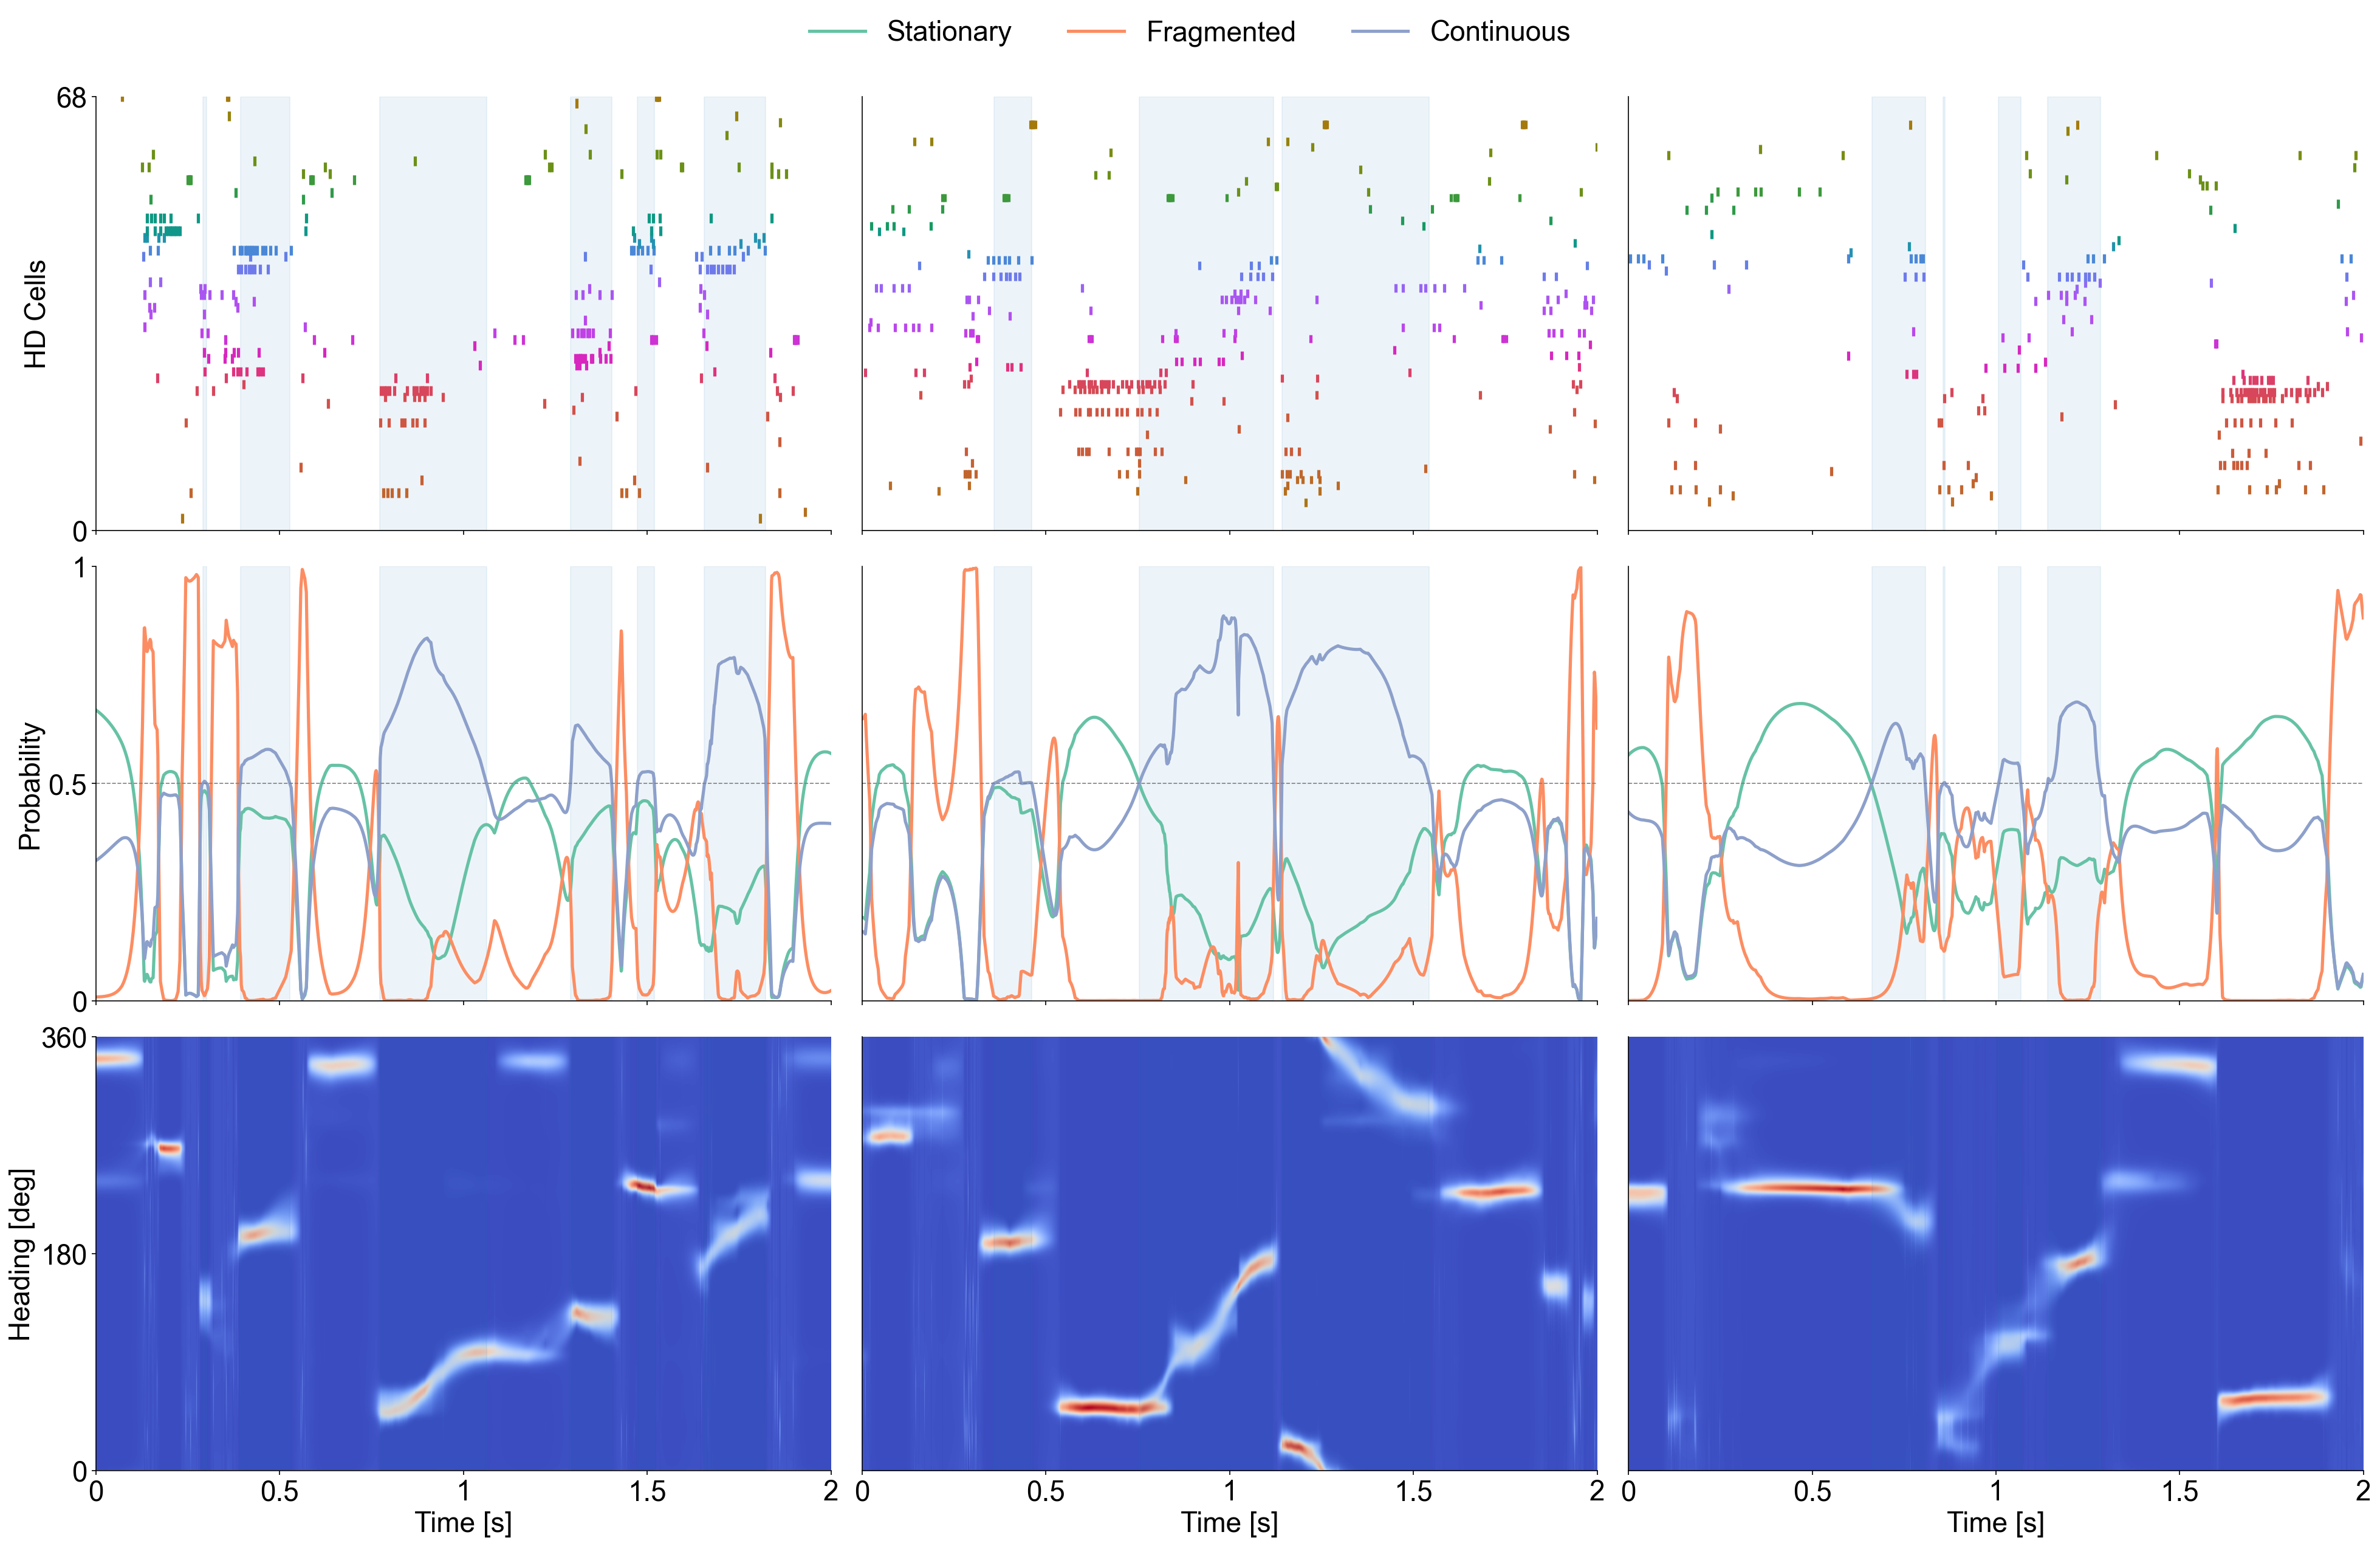

In [225]:
fig, axes = plt.subplots(3, 3, figsize=(26, 16), sharex="col",
                         height_ratios=[1, 1, 1])

for j, ep in enumerate(sweeps):
    ax_rast = axes[0, j]
    ax_prob = axes[1, j]
    ax_pos  = axes[2, j]

    tdf = states.restrict(ep)
    sweep_ep = tdf["continuous"].threshold(0.5).time_support
    t = tdf.times() - ep["start"]
    ep_spikes = hd_spikes.restrict(ep)

    # Spike raster
    offset = 0.4
    for i, uid in enumerate(sorted_units):
        if uid not in active:
            continue
        c = sorted_colors[i]
        if uid in ep_spikes.keys():
            ax_rast.eventplot(
                ep_spikes[uid].t - ep["start"],
                lineoffsets=offset + 0.5, linelengths=1.5, linewidths=2.5, color=c,
            )
        offset += 1

    # State probabilities
    for col, style in STATE_STYLES.items():
        ax_prob.plot(t, tdf[col], linewidth=2.5, **style)
    ax_prob.axhline(0.5, color="grey", ls="--", lw=0.8)
    ax_prob.set(ylim=(0, 1))

    # Decoded position
    features = position.restrict(ep).as_dataframe()
    im = ax_pos.imshow(features.T,
            aspect='auto',
            interpolation='bilinear',
            extent=[t[0], t[-1], position.metadata['position_bins'].min(), position.metadata['position_bins'].max()],
            origin='lower',
            cmap='coolwarm',
            )

    # Highlight continuous sweep epoch
    for start, end in sweep_ep.values:
        for ax in (ax_rast, ax_prob, ax_pos):
            ax.axvspan((start - ep["start"]).item(), (end - ep["start"]).item(),
                        color="#1f77b4", alpha=0.08)

    ax_pos.set(xlabel="Time [s]")
    ax_pos.set_xlim(0, 2)
    ax_pos.set_xticks([0, 0.5, 1, 1.5, 2], labels=["0", "0.5", "1", "1.5", "2"])

# Left-column labels & ticks
axes[0, 0].set_ylim(0, 68)
axes[0, 0].set_yticks([0, 68], labels=["0", "68"])
axes[0, 0].set_ylabel("HD Cells")
axes[1, 0].set_ylabel("Probability")
axes[1, 0].set_yticks([0, 0.5, 1], labels=["0", "0.5", "1"])
axes[2, 0].set_ylabel("Heading [deg]")
axes[2, 0].set_yticks([0, 180, 360], labels=["0", "180", "360"])

for j in range(1, 3):
    axes[0, j].set_yticks([])
    axes[1, j].set_yticks([])
    axes[2, j].set_yticks([])

# Shared legend
handles, labels = axes[1, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(STATE_STYLES), fontsize=22, bbox_to_anchor=(0.5, 1.06))

plt.show()
fig.savefig(INTERIM_DATA_PATH / unit_id / "sweep_combined.pdf", format="pdf", bbox_inches="tight")

## Figure 2 — State probabilities & decoded position

C:\Users\iii9781\AppData\Local\Temp\ipykernel_31212\3706694326.py:3: UserWarning: Adding colorbar to a different Figure <Figure size 2400x2400 with 9 Axes> than <Figure size 60x450 with 1 Axes> which fig.colorbar is called on.
  cb = fig_cb.colorbar(im, cax=ax_cb)
c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


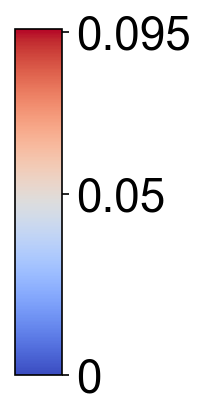

In [223]:
# ── Standalone colorbar ─────────────────────────────────────────────────────
fig_cb, ax_cb = plt.subplots(figsize=(0.4, 3))
cb = fig_cb.colorbar(im, cax=ax_cb)
cb.set_ticks([0, 0.05, 0.095])
cb.set_ticklabels(["0", "0.05", "0.095"])
plt.show()
# fig_cb.savefig(INTERIM_DATA_PATH / unit_id / "sweep_colorbar.pdf", format="pdf", bbox_inches="tight", transparent=True)

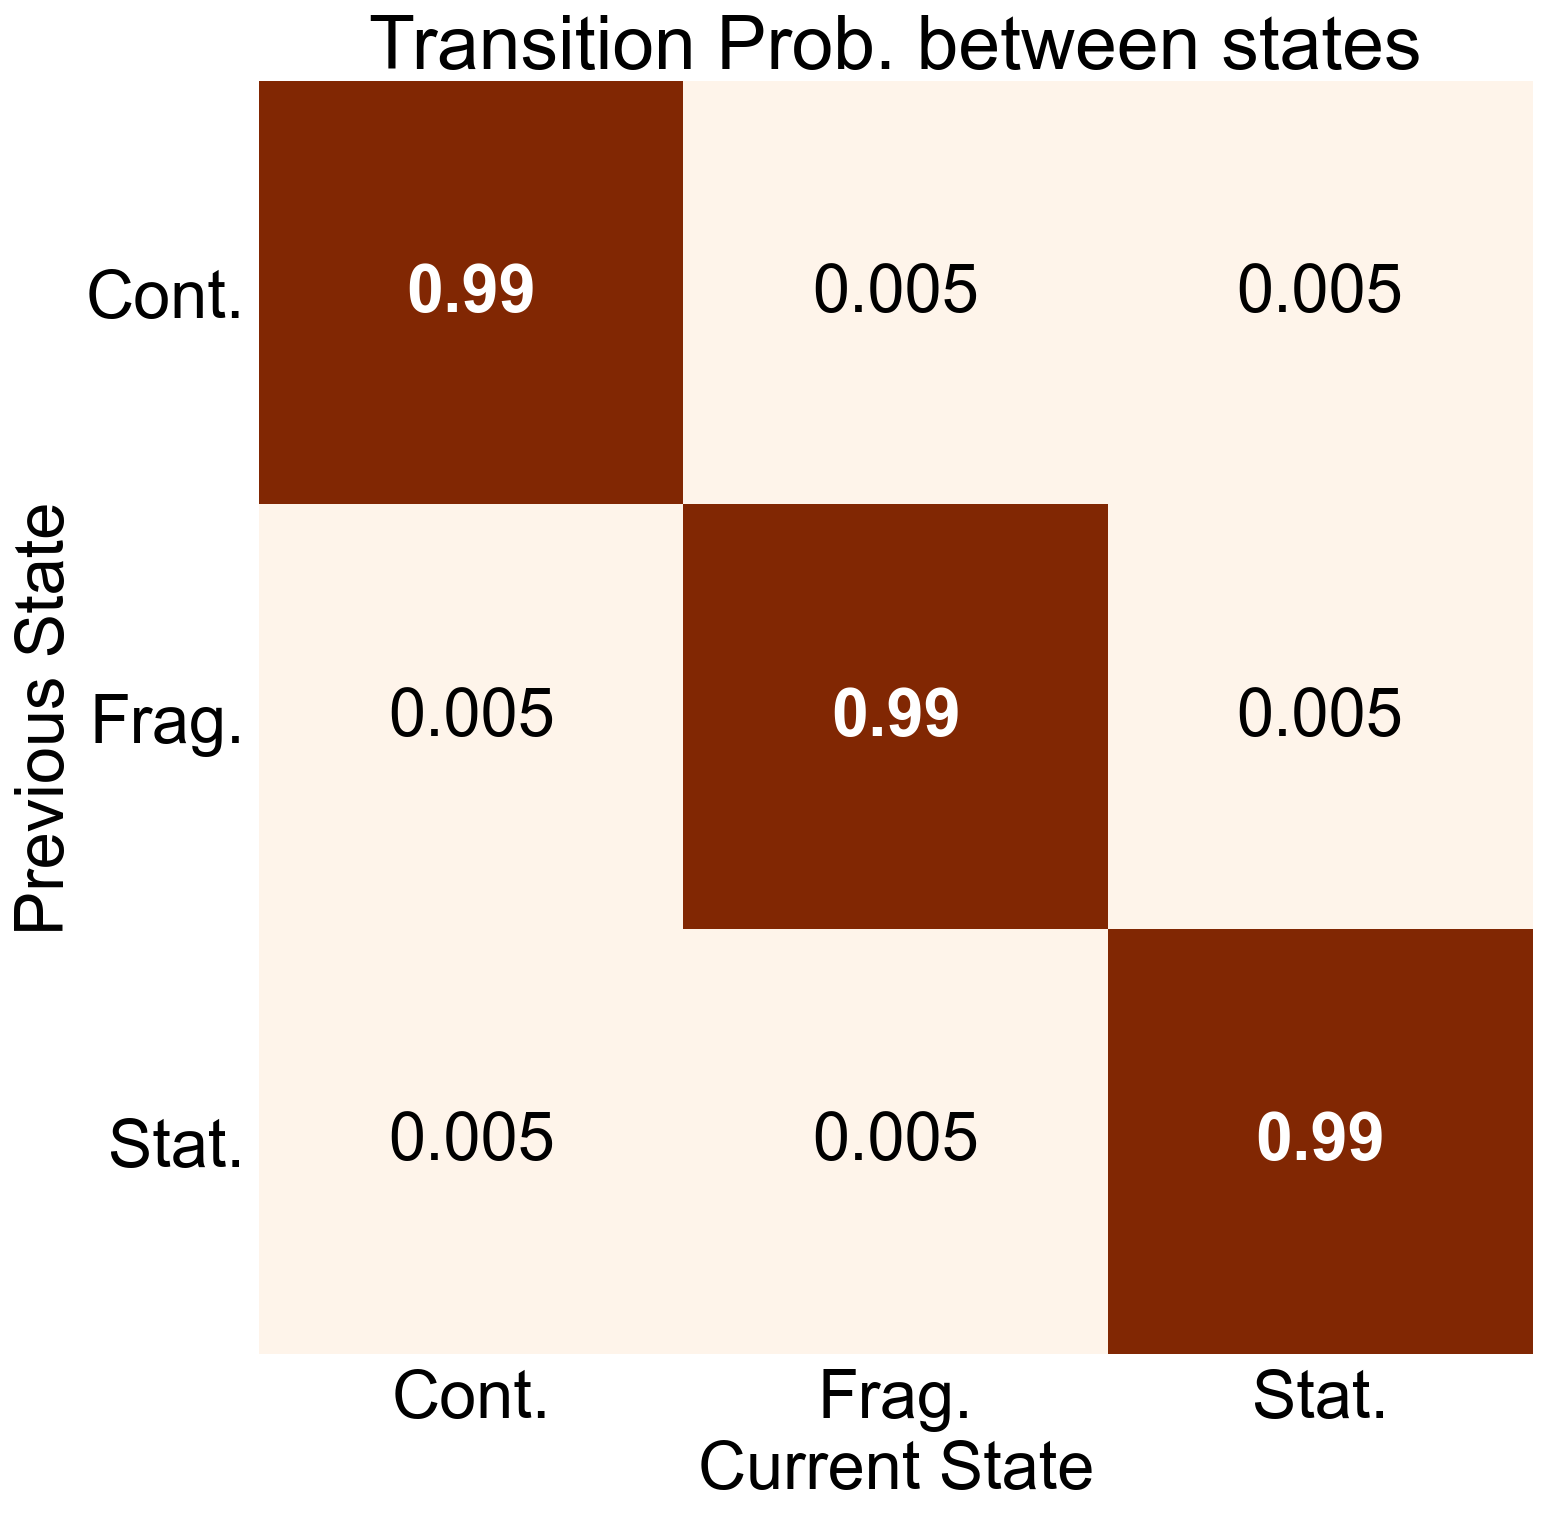

In [193]:
discrete_state_transition = np.array([[0.99 , 0.005, 0.005],
                                      [0.005, 0.99 , 0.005],
                                      [0.005, 0.005, 0.99 ]])

state_names = ['Cont.', 'Frag.', 'Stat.']

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(discrete_state_transition, cmap='Oranges', vmin=0, vmax=1)

# Annotate each cell
for i in range(3):
    for j in range(3):
        val = discrete_state_transition[i, j]
        color = "white" if val > 0.5 else "black"
        if i == j:
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=32, color=color, fontweight="bold")
        else:
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=32, color=color)


ax.set_xticks(range(3), labels=state_names, fontsize=32)
ax.set_yticks(range(3), labels=state_names, fontsize=32)
ax.set_xlabel("Current State", fontsize=32)
ax.set_ylabel("Previous State", fontsize=32)
ax.set_title("Transition Prob. between states", fontsize=36)
# # Colorbar
# cb = fig.colorbar(im, ax=ax, shrink=0.8)
# cb.set_label("Probability")

# Remove top/right spines that rcParams hides on normal axes
ax.spines[:].set_visible(False)
ax.tick_params(bottom=False, left=False)

plt.show()
fig.savefig(INTERIM_DATA_PATH / unit_id / "discrete_transition.pdf", format="pdf")